# NAMEs: Griffin Fitzpatrick
# NETIDs: grf47

# Homework 02: Gradient Descent and AdaGrad
This assignment focuses on two concepts: gradient descent, which we've covered in lecture, and AdaGrad, an algorithm that we have only briefly alluded to. In Section 1, you will implement gradient descent for two simple models. In Section 2, you will be introduced to AdaGrad and be asked to partially implement a toy version. 

While this notebook has a lot of text, it is much less coding than your previous assignments, so please don't be intimidated. You should read all of the instructional material carefully prior to doing any coding or responding to the questions. 

You may work in groups of up to 3 people for this assignment. When you are done, submit a PDF of this notebook with all cells run.

# Section 1: Implement Gradient Descent (75 points total)

In this section, you'll see how gradients guide parameter optimization, and you'll implement gradient descent to find optimal parameters for two simple models. This will prepare you for understanding how language models are trained using the same fundamental principles, just at a much larger scale.

### Import Packages

Run the code cell below to import the packages you will use in this activity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Perform Single-Parameter Optimization

You'll start with the simplest case of optimizing a parameter: finding the optimal value of parameter `a` for a quadratic function `y = a * x²`.  The parameter `a` controls the shape and curvature of the parabola. 
The function `y = a * x²` is the model, and the goal is to learn the value of `a` so that the model can accurately predict `y` from `x`.
Since the model predicts a continuous numeric value, it is a regression model.

*Note* that although the quadratic function produces a non-linear curve (a parabola), it is *linear in its parameter* `a`. This means the model’s output changes in direct proportion to `a`, making it a simple case for demonstrating how gradient descent adjusts parameters to reduce loss.

### Create and Plot the Training Data

The training data consists of 20 input-output pairs (training examples), where each input `x` has a corresponding label `y`.

During training, gradient descent iteratively updates the parameter `a`. At each step, the model computes predictions for all training inputs `x` and compares them to the corresponding labels `y` to calculate the loss. The gradient of this loss indicates how to adjust `a`, and the parameter is updated accordingly. This process repeats over many iterations, allowing the model to learn the value of `a` that best matches the training examples and can accurately predict `y` for new unseen inputs.

Run the code cell below to create the training data and plot every training example. You can see that the points do not perfectly follow a smooth parabola because of the added noise typical of real-world data, but by inspecting the graph or computing the slope, the value of `a` can be determined to be approximately 1.2. The goal is for the model to learn this value from the training data.

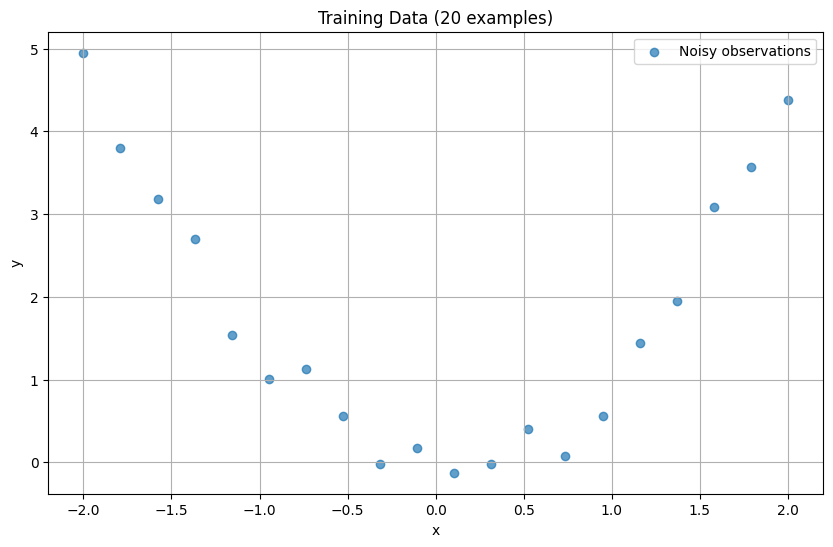

In [2]:
x_train = np.array([-2.0, -1.78947368, -1.57894737, -1.36842105, -1.15789474, -0.94736842, -0.73684211, -0.52631579,
     -0.31578947, -0.10526316, 0.10526316, 0.31578947, 0.52631579, 0.73684211, 0.94736842, 1.15789474, 
     1.36842105, 1.57894737, 1.78947368, 2.0])

y_train = np.array([4.94901425, 3.80117999, 3.18599631, 2.70400037, 1.53861825, 1.00676722, 1.12528739, 0.56264039,
     -0.02117473, 0.17606441, -0.12572891, -0.02005134, 0.40499865, 0.07753947, 0.55953296, 1.44017801, 1.94324208,
     3.08596395, 3.57025206, 4.37630889])

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.7, label='Noisy observations')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data (20 examples)')
plt.legend()
plt.grid(True)
plt.show()

### Implement Gradient Descent (25 points)

You will implement gradient descent to find the optimal value of `a`  that minimizes the difference between the model’s predictions and the true observations.

The code cell below defines the core components that make it work:

* A **prediction function** that uses the model equation `y = a * x²` to make predictions &mdash; it combines the input `x` with its learned parameter `a` to produce a continuous-valued output `y` based on this quadratic relationship.

* A **loss function** that measures how far the predictions are from the true observations. It uses the Mean Squared Error (MSE) loss function. It calculates the average of the squared differences between the model’s predictions and the true values, penalizing larger errors more strongly and providing a smooth surface for optimization. Different types of models use different loss functions depending on their goals. For example, MSE is commonly used for regression problems, while cross-entropy loss is typically used for classification problems.

* A **gradient function** that computes how the loss changes with respect to the parameter `a`, guiding the model on how to adjust the parameter to reduce the loss.

These components form the foundation of the gradient descent process. Once they’re defined, you'll use them inside a training loop to iteratively update `a` and find its optimal value.


In [3]:
def compute_predictions(a, x):
    """Compute predictions y = a * x^2"""
    # Your code here
    return [a * (xi ** 2) for xi in x]

def compute_loss(predictions, y_true):
    """Compute mean squared error loss"""
    # Your code here
    return sum((y - p)**2 for y, p in zip(y_true, predictions)) / len(y_true)

def compute_gradient(a, x, y_true):
    """Compute gradient of loss with respect to parameter a
    
    For y = a * x^2 and loss = mean((a*x^2 - y_true)^2),
    the gradient is: 2 * mean((a*x^2 - y_true) * x^2)
    """
    # Your code here
    n = len(y_true)
    g_sum = 0.0
    for xi, yi in zip(x, y_true):
        pred = a * (xi ** 2)
        g_sum += (pred - yi) * (xi ** 2)
    return (2.0/n)*g_sum

# Test your implementations
test_a = 1.0
test_pred = compute_predictions(test_a, x_train)
test_loss = compute_loss(test_pred, y_train)
test_grad = compute_gradient(test_a, x_train, y_train)

print(f"With a = {test_a}:")
print(f"Loss = {test_loss:.4f}")
print(f"Gradient = {test_grad:.4f}")

With a = 1.0:
Loss = 0.1984
Gradient = -1.3640


The code cell below implements the gradient descent training loop. A gradient descent loop repeatedly calculates the loss, determines the direction in which each parameter should be adjusted to reduce that loss (the gradient), and nudges all parameters slightly in those directions. This process is repeated until the loss is minimized and the model’s predictions improve.

Gradient descent stops iterating based on some stopping criterion, which tells the algorithm it’s “done” learning. Common approaches include setting a fixed number of iterations, stopping when the loss stops decreasing significantly, or stopping when the gradient becomes very small, indicating that the parameters are near a minimum. When this happens, the model is said to have **converged**: Training has stabilized and further updates no longer meaningfully change the parameters or reduce the loss.

In practice, implementations often combine these criteria to ensure efficient and effective training. In this activity, the stopping criterion is simply the number of iterations you set with `num_iterations`.

Complete and run the code cell below to train the model using gradient descent.

In [4]:
def train_quadratic_model(x_train, y_train, learning_rate, num_iterations):
    """Train quadratic model using gradient descent"""
    
    # Initialize parameter
    a = 0.5  # We start with a guess of 0.5
    
    # Track training progress
    loss_history = []
    a_history = [a]
    
    for iteration in range(num_iterations):
        #Fill in missing values below 

        # Compute predictions and loss
        predictions = compute_predictions(a, x_train)
        loss = compute_loss(predictions, y_train)
        
        # Compute gradient
        gradient = compute_gradient(a, x_train,y_train) 
        
        # Update parameter
        a = a - learning_rate * gradient
        
        # Record progress
        loss_history.append(loss)
        a_history.append(a)
        
        if iteration % 20 == 0:
            print(f"Iteration {iteration}: a = {a:.4f}, loss = {loss:.4f}")
    
    return a, loss_history, a_history

# Train the model with these hyperparameters
final_a, losses, a_values = train_quadratic_model(x_train, y_train, 0.01, 200)

print(f"\nFinal result: a = {final_a:.4f} (true approx value = {1.2})")

Iteration 0: a = 0.5526, loss = 1.8545
Iteration 20: a = 1.0522, loss = 0.1482
Iteration 40: a = 1.1508, loss = 0.0817
Iteration 60: a = 1.1703, loss = 0.0791
Iteration 80: a = 1.1741, loss = 0.0790
Iteration 100: a = 1.1749, loss = 0.0790
Iteration 120: a = 1.1750, loss = 0.0790
Iteration 140: a = 1.1750, loss = 0.0790
Iteration 160: a = 1.1751, loss = 0.0790
Iteration 180: a = 1.1751, loss = 0.0790

Final result: a = 1.1751 (true approx value = 1.2)


### Visualize the Training Process

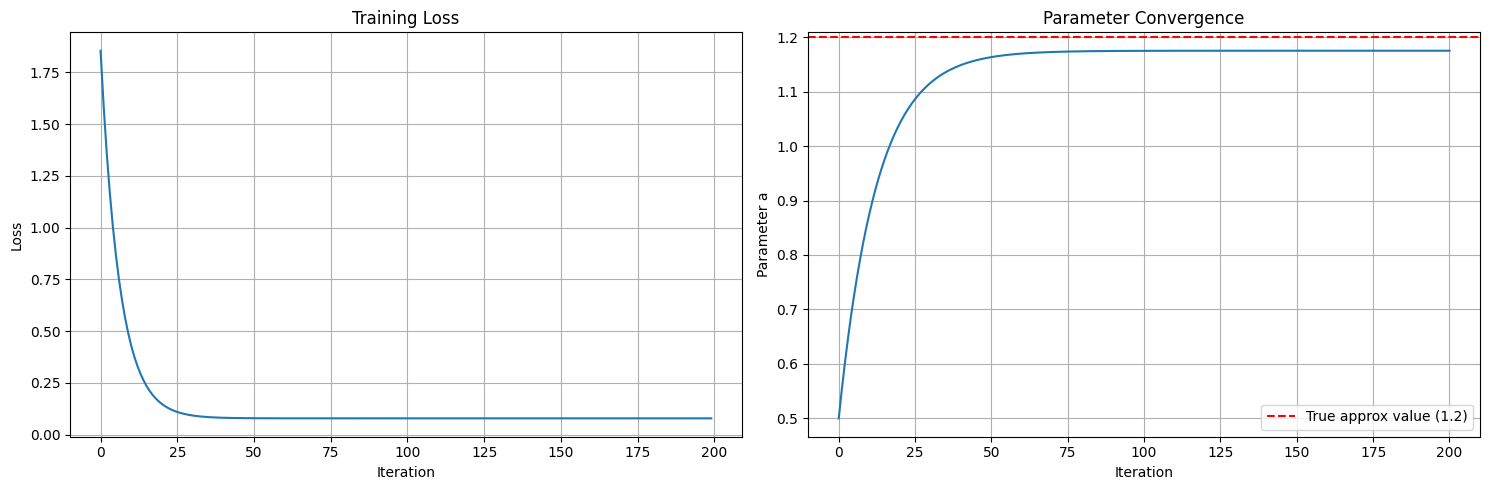

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss over time
ax1.plot(losses)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot parameter convergence
ax2.plot(a_values)
ax2.axhline(y=1.2, color='r', linestyle='--', label=f'True approx value ({1.2})')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter a')
ax2.set_title('Parameter Convergence')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Analyze the Output (10 points)

What do the output and these visualizations mean? Write a structured paragraph (5-10 sentences) interpreting your model's behavior, referencing the training logs and visualizations above.

The training logs and visualizations show that gradient descent is functioning correctly and converging toward the optimal parameter value. Initially, at iteration 0, the parameter a increases from its starting value of 0.5 to 0.5526, and the loss is relatively high at 1.8545. Over the first 20–40 iterations, the loss drops sharply (from 1.8545 to 0.0817), indicating that the model is quickly moving down a steep region of the loss surface. After roughly 60 iterations, both the loss (≈ 0.0790) and the parameter value begin to stabilize, suggesting that the gradient magnitude has become small and the algorithm is approaching a minimum. By iteration 180, ( a ) converges to approximately 1.1751, which is close to the true underlying value of 1.2. The loss curve confirms this behavior: it decreases rapidly at first and then flattens, reflecting diminishing updates as the algorithm nears convergence. Similarly, the parameter convergence plot shows a smooth asymptotic approach toward the true value (marked by the red dashed line), without oscillation or divergence. The slight gap between the final estimate (1.1751) and 1.2 is likely due to finite iterations and the chosen learning rate (0.01). Overall, the results demonstrate stable and successful optimization using gradient descent.

## Task 2: Perform Logistic Regression (Two-Parameter Optimization)

Now increase the number of learned parameters by implementing logistic regression. Logistic regression is a binary classification model that uses two parameters to draw a decision boundary between classes. It computes a linear combination of the input, 𝑧 = a⋅𝑥 + 𝑏 and passes it through a sigmoid function to output probabilities between 0 and 1. The decision boundary itself is the line a⋅𝑥 + 𝑏 = 0 where the model predicts a 50% probability for each class.

The two parameters are:
1. a is weight (slope) — it controls the steepness of the sigmoid curve; that is, how sharply it transitions from predicting 0 to predicting 1.
2. 𝑏 is the bias (intercept) — it shifts the sigmoid curve left or right along the x-axis, determining where the decision boundary (where probability = 0.5) lies.

Unlike the previous quadratic model, which predicted continuous values, logistic regression predicts the probability that an input belongs to a particular class (for example, “positive review” vs. “negative review”). It performs classification rather than regression. During training, gradient descent is learning both parameters (`a` and `b`) to find the sigmoid curve that best separates the two classes.

Logistic regression serves as a building block for understanding neural networks, which stack many logistic (sigmoid-like) units and train them using the same gradient descent process.


### Create and Plot the Training Data

Run the code cell below to create the training data and plot each training example.

In [ ]:
# Generate binary classification data
np.random.seed(42)
n_samples = 100

# Create two classes of data
x_class_0 = np.random.normal(-1, 0.8, n_samples//2)
x_class_1 = np.random.normal(1, 0.8, n_samples//2)

x_train = np.concatenate([x_class_0, x_class_1])
y_train = np.concatenate([np.zeros(n_samples//2), np.ones(n_samples//2)])

# Shuffle the data
shuffle_idx = np.random.permutation(len(x_train))
x_train = x_train[shuffle_idx]
y_train = y_train[shuffle_idx]

plt.figure(figsize=(10, 4))
plt.scatter(x_train[y_train==0], np.zeros_like(x_train[y_train==0]), alpha=0.6, label='Class 0', marker='o')
plt.scatter(x_train[y_train==1], np.ones_like(x_train[y_train==1]), alpha=0.6, label='Class 1', marker='s')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Binary Classification Data')
plt.legend()
plt.grid(True)
plt.show()

### Implement Gradient Descent

Just as with the quadratic model, logistic regression includes the same three core components, adapted for classification. It also includes a `sigmoid()` function. The code cell below defines these core components:

* A **sigmoid function** that takes an array of real-valued inputs and transforms each value into a probability between 0 and 1. Large positive inputs produce values close to 1, large negative inputs produce values close to 0, and inputs near 0 map to about 0.5. The function returns a corresponding array of probabilities.

* A **prediction function** that applies the model’s learned parameters (weight `a` and bias `b`) to the input `x`, computing the linear term `a * x + b` for all values in `x`. It then passes these values through the sigmoid function to generate a predicted probability for each input.

* A **loss function** that measures how far the model’s predicted probabilities are from the true binary labels. It uses the binary cross-entropy (logistic) loss, which measures the average difference between predicted probabilities and the labels. It penalizes confident but incorrect predictions more heavily, encouraging the model to assign high probabilities to true positives and low probabilities to true negatives. A small constant (epsilon) is added to prevent taking the logarithm of zero for numerical stability. This loss function is ideal for classification tasks, where the goal is to predict probabilities for discrete classes, unlike MSE, which is better suited for regression problems.

* A **gradient function** that computes how the loss changes with respect to the model’s parameters (`a` and `b`), guiding the model on how to adjust the parameters to reduce the loss.

### Deriving the Gradients for Logistic Regression

This part is a little tricky, so we'll give you most of the math here and then leave the last bit for you to work out. 

We have a logistic regression model that makes predictions:

$$\hat{y} = \sigma(ax + b)$$

where $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ is the **sigmoid function**, and $a$, $b$ are the parameters we want to learn.

We measure how wrong our predictions are using the **binary cross-entropy loss**:

$$L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \ln(\hat{y}_i) + (1 - y_i)\ln(1 - \hat{y}_i)\right]$$

**Our goal:** Find $\dfrac{\partial L}{\partial a}$ and $\dfrac{\partial L}{\partial b}$ — how much the loss changes when we nudge $a$ or $b$.

#### The Chain Rule Strategy

Instead of differentiating the entire expression at once, we can break it into a chain of simpler steps. Define the intermediate variable $z = ax + b$, so that $\hat{y} = \sigma(z)$. Then,

$$\frac{\partial L}{\partial a}
= \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{Step 3}}
\cdot \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\text{Step 2}}
\cdot \underbrace{\frac{\partial z}{\partial a}}_{\text{Step 1}}$$

Let's find each piece one at a time.


#### Step 1: How does $z$ depend on $a$ and $b$?

We defined $z = ax + b$. This is just a linear function, so the derivatives are straightforward:

$$\frac{\partial z}{\partial a} = x \qquad \qquad \frac{\partial z}{\partial b} = 1$$

(Here $x$ is treated as a constant — it's our data, not a parameter.)


#### Step 2: The Sigmoid Derivative

We need $\dfrac{d\sigma}{dz}$ where $\sigma(z) = \dfrac{1}{1 + e^{-z}}$.

Rewrite as $\sigma = (1 + e^{-z})^{-1}$ and apply the chain rule:

$$\frac{d\sigma}{dz} = -1 \cdot (1 + e^{-z})^{-2} \cdot (-e^{-z})
= \frac{e^{-z}}{(1 + e^{-z})^2}$$

Now notice a useful identity. Since $\sigma(z) = \dfrac{1}{1+e^{-z}}$, we have:

$$1 - \sigma(z) = \frac{e^{-z}}{1 + e^{-z}}$$

Multiplying these together:

$$\sigma(z)\bigl(1 - \sigma(z)\bigr) = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \frac{e^{-z}}{(1+e^{-z})^2}$$

This matches what we derived above, so:

$$\boxed{\frac{d\sigma}{dz} = \sigma(z)\bigl(1 - \sigma(z)\bigr) = \hat{y}(1 - \hat{y})}$$

This is a result that's worth remembering!


#### Step 3: How does the loss depend on $\hat{y}$?

Starting from the loss for a single data point (you'll average at the end):

$$L_i = -\left[y\ln(\hat{y}) + (1 - y)\ln(1 - \hat{y})\right]$$

Take the derivative with respect to $\hat{y}$, using $\dfrac{d}{dx}\ln(x) = \dfrac{1}{x}$:

$$\frac{\partial L_i}{\partial \hat{y}}
= -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}}$$

Combine over the common denominator $\hat{y}(1 - \hat{y})$:

$$= \frac{-y(1-\hat{y}) + (1-y)\hat{y}}{\hat{y}(1-\hat{y})}
= \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1-\hat{y})}
= \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$


#### Step 4: Multiply the Chain Together and Average

We'll leave this part for you: you have all the pieces, so it's just a matter of putting them together!



### Implementation (30 points) 
Now, fill in the cell below to train your logistic regression model. 

In [ ]:
def sigmoid(z):
    """Sigmoid activation function with numerical stability"""
    # Clip to prevent overflow
    z = np.clip(z, -500, 500)
    # Your code here
    ...

def logistic_predictions(a, b, x):
    """Compute logistic regression predictions: sigmoid(a*x + b)"""
    # Your code here
    ...

def logistic_loss(predictions, y_true):
    """Compute binary cross-entropy loss"""
    # Add small epsilon to prevent log(0)
    eps = 1e-15
    predictions = np.clip(predictions, eps, 1 - eps)
    # Your code here
    ...

def logistic_gradients(a, b, x, y_true):
    """Compute gradients of loss with respect to parameters a and b"""
    predictions = logistic_predictions(a, b, x)
    errors = predictions - y_true

    # Your code here 
    grad_a = ... 
    grad_b = ... 
    
    return grad_a, grad_b

# Test the implementations
test_a, test_b = 1.0, 0.0
test_preds = logistic_predictions(test_a, test_b, y_train)
test_loss = logistic_loss(test_preds, y_train)
test_grad_a, test_grad_b = logistic_gradients(test_a, test_b, x_train, y_train)

print(f"With a={test_a}, b={test_b}:")
print(f"Loss = {test_loss:.4f}")
print(f"Gradient a = {test_grad_a:.4f}")
print(f"Gradient b = {test_grad_b:.4f}")

The code cell below implements the gradient descent training loop. It starts with random guesses for the slope (`a`) and intercept (`b`), then repeatedly updates both parameters using gradient descent to reduce the loss.  Unlike the single-parameter quadratic example, this version shows how gradient descent scales to multiple parameters &mdash; the same principle that enables training neural networks with even millions or billions of parameters.


Fill in the missing code below and then run the cell to train your model.

In [ ]:
def train_logistic_regression(x_train, y_train, learning_rate, num_iterations, print_frequency=200):
    """Train logistic regression using gradient descent"""
    
    # Initialize parameters
    a = 0.0
    b = 0.0
    
    # Track training progress
    loss_history = []
    params_history = [(a, b)]
    
    for iteration in range(num_iterations):
        # Fill in the missing code below

        # Compute predictions and loss
        predictions = ... 
        loss = ... 
        
        # Compute gradients
        grad_a, grad_b = ... 
        
        # Update parameters
        a = ... 
        b = ... 
        
        # Record progress
        loss_history.append(loss)
        params_history.append((a, b))
        
        if iteration % print_frequency == 0:  # Use the parameter instead of hardcoded 200
            print(f"Iteration {iteration}: a={a:.4f}, b={b:.4f}, loss={loss:.4f}")
    
    return a, b, loss_history, params_history

# Train the model
final_a, final_b, losses, param_history = train_logistic_regression(
    x_train, y_train, 0.5, 1000)

print(f"\nFinal parameters: a = {final_a:.4f}, b = {final_b:.4f}")

### Visualize the Training Process

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training loss
ax1.plot(losses)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot the final decision boundary
x_range = np.linspace(-4, 4, 100)
final_probs = logistic_predictions(final_a, final_b, x_range)

ax2.scatter(x_train[y_train==0], y_train[y_train==0], alpha=0.6, label='Class 0', marker='o')
ax2.scatter(x_train[y_train==1], y_train[y_train==1], alpha=0.6, label='Class 1', marker='s')
ax2.plot(x_range, final_probs, 'r-', linewidth=2, label='Learned probability')
ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Decision boundary')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability')
ax2.set_title('Logistic Regression Results')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Analyze the Output (10 points)

##### What does this output tell you about the training process? Can you spot which iterations encompass **rapid learning**, **refinement**, and **model convergence**? 
Write a paragraph (5-10 sentences) that references the training process and the visualizations above. 

# Section 2: Implement the Adaptive Gradient Algorithm (AdaGrad) (25 points total)

The learning rate controls how big a step we take when adjusting a model's parameters.

In gradient descent, the model repeatedly computes the gradient of the loss function given a small data sample and moves in a direction that reduces the error on the current instance.
If the learning rate is too high, these steps are too large and may overshoot the best solution.
If it’s too low, the steps are tiny, and the model learns very slowly. Choosing an appropriate learning rate is one of the most important decisions in training — it determines how efficiently the model converges.

#### The Challenge of Language Data

As you've seen in our recent in-class activity, training a classifier on text data presents a unique challenge that stems from the fundamental nature of language itself. Consider, for example, a simple genre classifier for horror vs. science-fiction:

- **Rare words** (like "ghost" or "laser") are highly informative when they appear but occur infrequently in our training data.
- **Common words** (like "the" or "and") appear in almost every document but provide less discriminative information.

In a simple model such as logistic regression, each token has a single weight parameter that determines how much that token influences the model’s prediction. You can think of that weight as being associated with the token. In large language models (LLMs), each token is represented by a numerical vector — a set of parameters that captures information about the token’s meaning and context.

A language model learns how these tokens behave in context. During training, whenever a token appears in the training data, the parameters of its vector are updated based on the gradient. Over time, the model adjusts these numbers so that tokens develop numerical representations capturing their meanings and relationships to other tokens, even though the words themselves never change.

For example, tokens like “ghost” become associated with patterns found in horror texts, while “laser” becomes linked to science-fiction contexts.

Because common words (tokens) appear in many training examples, the parameters associated with them are updated much more frequently.
If the learning rate is too high, these frequent and large updates can cause the parameters to fluctuate back and forth around the optimal values instead of stabilizing. If the learning rate is too low, parameters for rare but informative tokens change only slightly when those tokens appear, so the model barely learns from them.

For example, a frequent token like “the” is updated thousands of times during training, while a rare token like “ghost” might appear only a few times. As a result, the model quickly learns how “the” behaves but may never fully adjust the parameters that represent “ghost,” leaving its meaning underdeveloped in the learned representation.

This imbalance creates a challenge for language models that use a single, fixed learning rate.

#### The Solution: Adaptive Learning Rates That Are Parameter-Specific 

To address this problem, adaptive optimization methods such as AdaGrad adjust the learning rate independently for each parameter, allowing the model to take smaller steps for frequently updated parameters and larger steps for rare ones.


**AdaGrad** (Adaptive Gradient Algorithm) solves this problem by giving each parameter its own learning rate that adapts based on the parameter's update history.  It updates parameters with an awareness of the adjustments made in the past: If it made large changes to a parameter earlier, it becomes more cautious about changing it again; if it made only small changes, it’s more willing to adjust it further.

Here's how it works:

1. **Track update history**: For each parameter, AdaGrad keeps a running sum of all the squared gradients it has seen.
2. **Scale learning rate inversely**: Parameters that have received many large updates get smaller learning rates, while parameters that have been updated less frequently get larger learning rates.
3. **Automatic balancing**: This means common words (which generate frequent updates) automatically get smaller learning rates over time, while rare words (which generate infrequent updates) maintain larger learning rates.

The formula for the AdaGrad update is:   

$$\alpha_t = \frac{\alpha}{\sqrt{G_t + \epsilon}}$$
where $\alpha_t$ is the adaptive learning rate at time $t$, $\alpha$ is the base learning rate, $G_t$ is the sum of squared gradients up to time $t$, and $\epsilon$ is a small constant that avoids divide-by-zero errors and extremely small denominators.

**A Simple Example**

Imagine a parameter whose gradient alternates between -1 and 1.  With a **fixed learning rate**, the parameter would keep bouncing back and forth around the minimum forever.  

With **AdaGrad**, each step adds the square of the current gradient to $G_t$. As $G_t$ grows over time, the denominator ${G_t + \epsilon}$ increases, which makes the effective learning rate $\alpha_t$ decrease. The steps therefore become smaller and smaller, allowing the parameter to settle near a stable value instead of oscillating indefinitely.

Neural language models have millions or billions of parameters, all working together to interpret inputs and produce outputs. A change to any one parameter can potentially affect the behavior of every other parameter. AdaGrad helps keep such massive systems stable in the face of noisy input from uncurated sources like web documents by ensuring that frequently updated parameters become increasingly conservative in their updates, while rarely updated parameters remain sensitive to new information.

In this section, you’ll implement the AdaGrad algorithm on this simple one-parameter example to observe how the learning rate adapts over time, explore how a small stability constant affects this process, and compare its memory usage to standard gradient descent. You'll explore how this adaptive approach enables the training of large-scale language models.

### Imports 

In [6]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

### Plotting functions 

We'll use this plotting function in this activity

In [7]:
def plot_data_(steps, gradient_values, adaptive_lrs, parameter_values, fig=None, axes=None, label=None, color=None):
   
    if fig is None or axes is None:
        fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    ax1, ax2, ax3 = axes

    set_color = color is not None 

    # Plot 1: Gradient values
    ax1.step(steps, gradient_values, where='post', linewidth=2.5, color='red', alpha=0.8)
    ax1.scatter(steps[1:], gradient_values[1:], color='red', s=50, zorder=5)
    ax1.set_ylabel('Gradient', fontsize=12)
    ax1.set_title('Adagrad Effect on Parameter Updates', fontsize=14, fontweight='bold')
    ax1.set_ylim(-1.5, 1.5)
    ax1.grid(True, alpha=0.3)

    
    
    # Plot 2: Adaptive learning rate
    if not set_color: 
        color='blue'
    
    ax2.plot(steps, adaptive_lrs, 'o-', linewidth=1.5, color=color, alpha=0.5, markersize=6, label=label)
    ax2.set_ylabel('Adaptive Learning Rate', fontsize=12)
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Parameter value
    if not set_color:
        color = 'green'
    ax3.plot(steps, parameter_values, 'o-', linewidth=1.5, color=color, alpha=0.5, markersize=6, label=label)
    ax3.scatter(steps[1:], parameter_values[1:], color='green', s=50, zorder=5)
    ax3.set_xlabel('Step', fontsize=12)
    ax3.set_ylabel('Parameter Value', fontsize=12)
    ax3.grid(True, alpha=0.3)

    return fig, axes  # Return them so you can reuse later

## Explore Basic AdaGrad (10 points)

The code below defines a function that implements AdaGrad on the simple one-parameter example described above. It simulates the parameter update process that occurs during training, showing how a parameter (such as the weight parameter for a common word like “the” in our classifier) is updated by gradients that alternate between −1 and +1. This mirrors a common optimization scenario where gradients push a parameter back and forth, often due to a high learning rate, causing it to oscillate rather than converge. The function illustrates how the AdaGrad algorithm automatically adjusts the learning rate over time.

**Key components:**
- **One parameter** starting at 0.0 (representing a token's weight)
- **Alternating gradients** (-1, +1, -1, +1...) that would normally cause wild oscillation
- **AdaGrad's adaptive mechanism** that tracks the sum of squared gradients and reduces the learning rate over time. 


Finish and run the cell below to define the function `implement_adagrad()`.

In [11]:
def implement_adagrad(epsilon=1e-8):
    """
    Demonstrate AdaGrad on a single parameter with alternating gradients (+/-1).

    - Starts parameter at 0.0 with base learning_rate = 1.0.
    - Maintains G_t = sum of squared gradients.
    - Uses adaptive_lr = learning_rate / sqrt(G_t + epsilon).
    - Prints per-step updates and returns timeseries for plotting:
      steps, gradient_values, adaptive_lrs, parameter_values.
    """

    parameter = 0.0  # Starting parameter value
    learning_rate = 1.0  # Base learning rate
    #epsilon = 1e-8  # Small constant to prevent division by zero
    sum_squared_gradients = 0.0  # Accumulated sum of squared gradients
    
    # Gradients that alternate between -1 and 1
    gradients = [-1, 1, -1, 1, -1, 1, -1, 1]
    
    # Store data for plotting
    data = []
    steps = [0]  # Include step 0 for initial state
    gradient_values = [0]  # No gradient at step 0
    adaptive_lrs = [learning_rate]  # Initial learning rate
    parameter_values = [parameter]  # Initial parameter value
    
    print("Adagrad Updates:")
    print(f"Initial parameter: {parameter:.4f}")
    print(f"Learning rate: {learning_rate}")
    print(f"Epsilon: {epsilon}")
    print("-" * 50)
    
    for step, gradient in enumerate(gradients, 1):
        # Fill in the missing code below

        # Accumulate squared gradient
        sum_squared_gradients += gradient ** 2
        
        # Compute adaptive learning rate
        adaptive_lr = learning_rate / ((sum_squared_gradients ** 0.5) + epsilon)
        
        # Update parameter
        old_parameter = parameter
        parameter = parameter - adaptive_lr * gradient
        
        # Store for plotting
        steps.append(step)
        gradient_values.append(gradient)
        adaptive_lrs.append(adaptive_lr)
        parameter_values.append(parameter)
        
        print(f"Step {step}:")
        print(f"  Gradient: {gradient:2d}")
        print(f"  Sum of squared gradients: {sum_squared_gradients:.1f}")
        print(f"  Adaptive learning rate: {adaptive_lr:.4f}")
        print(f"  Parameter: {old_parameter:.4f} → {parameter:.4f}")
        print(f"  Actual update: {parameter - old_parameter:+.4f}")
        print()

    return steps, gradient_values, adaptive_lrs, parameter_values

The code below calls `implement_adagradand()` and plots the results. Assuming the code you wrote is correct, it will produce plots that visualize three processes happening at once:

1. The **gradients** continue to alternate between –1 and +1 (the first plot), representing repeated pushes in opposite directions.

2. The **adaptive learning rate** steadily decreases over time as AdaGrad accumulates squared gradients, recognizing that this parameter has been updated many times (the middle plot).

3. The **parameter value** gradually stabilizes, stopping its back-and-forth oscillation even though the gradients continue to switch direction at each step(bottom plot).

Together, these plots show how AdaGrad automatically reduces the learning rate for frequently updated parameters, allowing the model to converge more smoothly.

Adagrad Updates:
Initial parameter: 0.0000
Learning rate: 1.0
Epsilon: 1e-08
--------------------------------------------------
Step 1:
  Gradient: -1
  Sum of squared gradients: 1.0
  Adaptive learning rate: 1.0000
  Parameter: 0.0000 → 1.0000
  Actual update: +1.0000

Step 2:
  Gradient:  1
  Sum of squared gradients: 2.0
  Adaptive learning rate: 0.7071
  Parameter: 1.0000 → 0.2929
  Actual update: -0.7071

Step 3:
  Gradient: -1
  Sum of squared gradients: 3.0
  Adaptive learning rate: 0.5774
  Parameter: 0.2929 → 0.8702
  Actual update: +0.5774

Step 4:
  Gradient:  1
  Sum of squared gradients: 4.0
  Adaptive learning rate: 0.5000
  Parameter: 0.8702 → 0.3702
  Actual update: -0.5000

Step 5:
  Gradient: -1
  Sum of squared gradients: 5.0
  Adaptive learning rate: 0.4472
  Parameter: 0.3702 → 0.8175
  Actual update: +0.4472

Step 6:
  Gradient:  1
  Sum of squared gradients: 6.0
  Adaptive learning rate: 0.4082
  Parameter: 0.8175 → 0.4092
  Actual update: -0.4082

Step 7:
  Grad

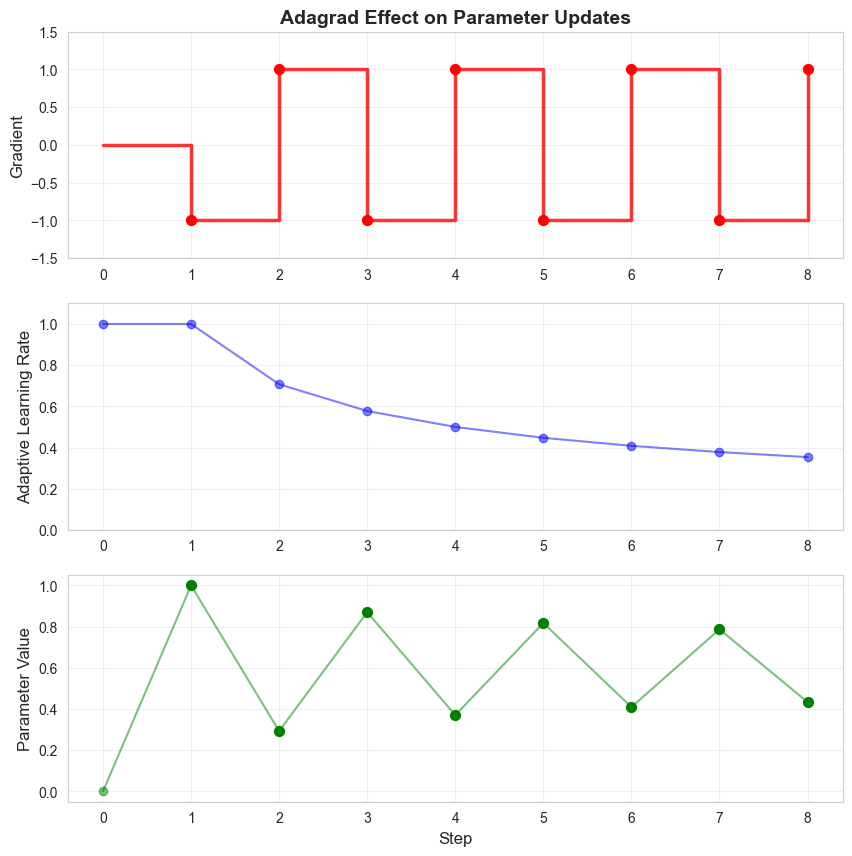

In [12]:
steps, gradient_values, adaptive_lrs, parameter_values = implement_adagrad()
fig, axes = plot_data_(steps, gradient_values, adaptive_lrs, parameter_values) 

## Analyze Basic AdaGrad Behavior (5 points)

Write a brief response to each of the following questions.

### 1. Does the adaptive learning rate increase or decrease over time? Why does this happen?

The adaptive learning rate decreases over time. With Gt in the denominator, as Gt grows with each iteration, it causes alpha to shrink.

### 2. What extra information does AdaGrad need to store for each compared to standard gradient descent?

Standard gradient descent only needs to store the current parameter value during each update. AdaGrad must store, for each parameter, the running sum of squared gradients.  

## Explore the Epsilon Constant

Let's understand what **epsilon** ($\epsilon$) does in the AdaGrad formula:

$$\alpha_t = \frac{\alpha}{\sqrt{G_t + \epsilon}}$$

**Epsilon** is a small constant added to prevent **division by zero**. When training starts, the sum of squared gradients $G_t$ is 0, which would make the denominator 0 and cause the algorithm to fail.

However, $\epsilon$ also influences how aggressively AdaGrad adapts the learning rate.

The code cell below applies AdaGrad to the same one-parameter example using four different epsilon values, allowing you to observe how this constant affects the adaptive learning rate.


**You don't need to anything to the cell below besides run it:** if the code you wrote earlier is correct, it will run just fine. 


TESTING EPSILON = 1e-08
Adagrad Updates:
Initial parameter: 0.0000
Learning rate: 1.0
Epsilon: 1e-08
--------------------------------------------------
Step 1:
  Gradient: -1
  Sum of squared gradients: 1.0
  Adaptive learning rate: 1.0000
  Parameter: 0.0000 → 1.0000
  Actual update: +1.0000

Step 2:
  Gradient:  1
  Sum of squared gradients: 2.0
  Adaptive learning rate: 0.7071
  Parameter: 1.0000 → 0.2929
  Actual update: -0.7071

Step 3:
  Gradient: -1
  Sum of squared gradients: 3.0
  Adaptive learning rate: 0.5774
  Parameter: 0.2929 → 0.8702
  Actual update: +0.5774

Step 4:
  Gradient:  1
  Sum of squared gradients: 4.0
  Adaptive learning rate: 0.5000
  Parameter: 0.8702 → 0.3702
  Actual update: -0.5000

Step 5:
  Gradient: -1
  Sum of squared gradients: 5.0
  Adaptive learning rate: 0.4472
  Parameter: 0.3702 → 0.8175
  Actual update: +0.4472

Step 6:
  Gradient:  1
  Sum of squared gradients: 6.0
  Adaptive learning rate: 0.4082
  Parameter: 0.8175 → 0.4092
  Actual update

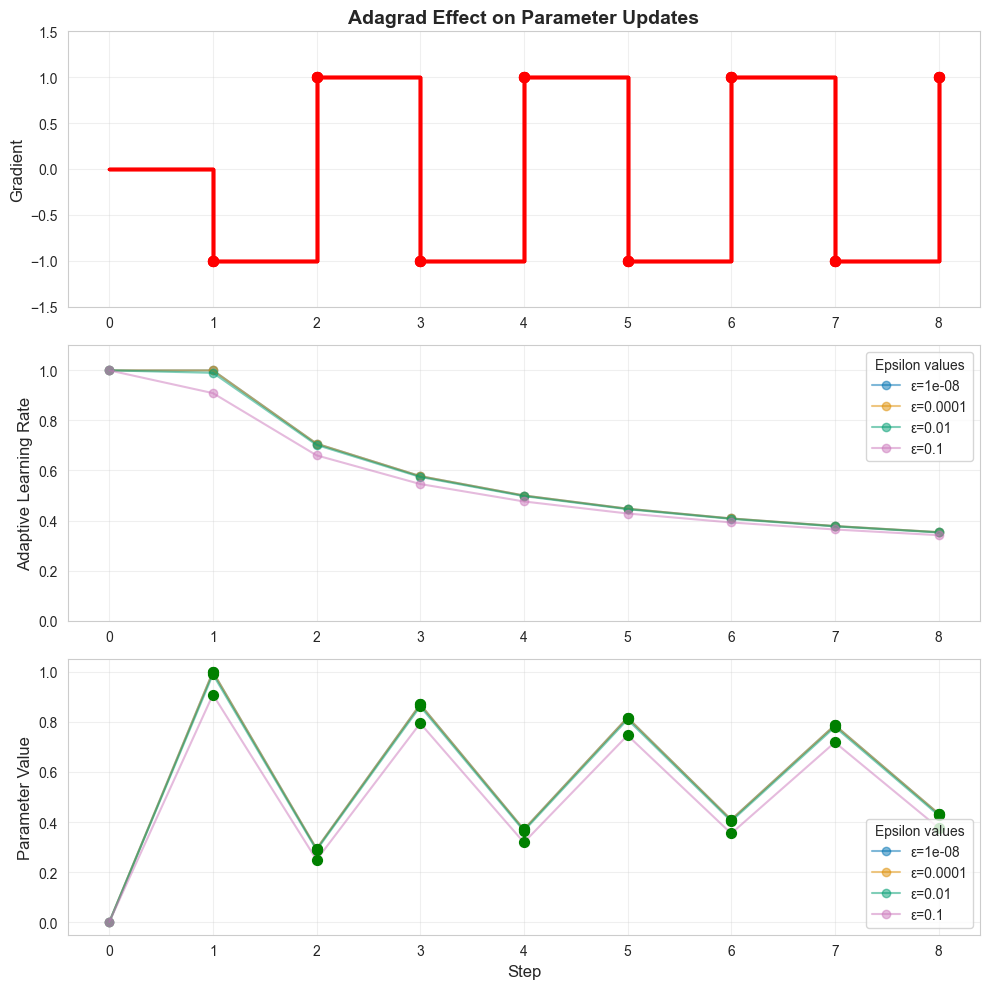

In [13]:
epsilon_values = [1e-8, 1e-4, 1e-2, 0.1]

colors = ['#0173b2', '#de8f05', '#029e73', '#cc78bc']  
fig, axes = None, None

# Store results for all epsilon values
all_results = {}

for i, epsilon in enumerate(epsilon_values):
    print(f"\n{'='*50}")
    print(f"TESTING EPSILON = {epsilon}")
    print(f"{'='*50}")
    
    steps, gradient_values, adaptive_lrs, parameter_values = implement_adagrad(epsilon)
    fig, axes = plot_data_(steps, gradient_values, adaptive_lrs, parameter_values, fig=fig, axes=axes, label=f"ε={epsilon}", color=colors[i])
    
    # Store results for comparison
    all_results[epsilon] = {
        'steps': steps,
        'gradient_values': gradient_values,
        'adaptive_lrs': adaptive_lrs,
        'parameter_values': parameter_values
    }

print("\n" + "="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)
print(f"{'Epsilon':<12} {'Final LR':<12} {'Final Param':<12}")
print("-" * 36)
for epsilon in epsilon_values:
    final_lr = all_results[epsilon]['adaptive_lrs'][-1]
    final_param = all_results[epsilon]['parameter_values'][-1]
    print(f"{epsilon:<12} {final_lr:<12.6f} {final_param:<12.4f}")


axes[1].legend(title="Epsilon values")
axes[2].legend(title="Epsilon values")
plt.tight_layout()
plt.show()

## Reflection (10 points)

Write a brief response to each of the following questions, justified by the figures and outputs from the cells above.

### 1. What happens when you make epsilon larger?

Making epsilon larger reduces the adaptive learning rate and shrinks parameter updates, which makes learning more conservative. In my results, the final learning rate is smaller for the larger epsilon. (e = 1e-8 --> 0.353553 vs e = 0.1 --> 0.341480)

### 2. Why might epsilon be important for numerical stability?

Epsilon is important for numerical stability because it prevents division by zero or extremely small numbers in the AdaGrad update. By adding epsilon, the denominator is always positive and not zero, preventing crashes, undefined values, and extremely large parameter updates

### 3. How does AdaGrad balance stability (not oscillating) with continued learning?

AdaGrad balances stability and continued learning by shrinking the learning rate over time as squared gradients accumulate, which reduces oscillations. However, because the learning rate never reaches zero due to epsilon, parameters continue to update gradually, allowing ongoing learning.

### 4. How might this apply to fine-tuning large language models, where some parameters have been updated extensively during the pretraining?

In fine-tuning LLM's, many parameters have already accumulated large gradient during pretraining. With AdaGrad, those parameters would have large Gt, resulting in very small learning rates, helping preserve learned knowledge and preventing drastic changes. Meanwhile, less updated or newly introduced params would retian larger learning rates, allowing them to adapt more quickly to the new task.

### 5. Can you think of any problems with AdaGrad's approach? (Hint: What happens to the learning rate over very long training?)

Because AdaGrad accumulates all past squared gradients, Gt grows monotonically approaching zero over very long training. Thus, as the learning rate keeps shrinking it can come extremely small, effectively stopping learning. While this is actually the fundamental idea behind AdaGrads approach, this means that training may stall prematurely, the modle can struggle to adapt later in training, or it may stop making meaningful progress even if it hasn't reached an optimal solution.